# Synthetic covariance matrices

This example illustrates the different synthetic covariance matrix models
provided by `covseisnet.synthetic`. Starting from the station geometry of
the *UnderVolc* array at Piton de la Fournaise, we compute:

1. a **plane-wave** covariance — rank-1, perfectly coherent,
2. an **isotropic surface-noise** covariance — full-rank, described by
   the Bessel function $J_0$,
3. an **isotropic volume-noise** covariance — full-rank, described by the
   sinc function,
4. a **spherical-wave** covariance from a point source — rank-1 with
   amplitude decay,
5. a **random (incoherent) noise** covariance — approaches the identity
   matrix.

For each model we display the modulus of the covariance matrix and its
eigenvalue spectrum, which directly relates to the coherence of the wavefield.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import covseisnet as csn
import covseisnet.synthetic as syn

## Station geometry

We load the UnderVolc waveforms and their inventory so that every trace
carries geographical coordinates.  We then extract the list of
`obspy.core.trace.Stats` objects — the only input required by all
`covseisnet.synthetic` functions.

In [2]:
# Load waveforms and attach station coordinates
stream = csn.read("../data/undervolc.mseed")
stream.assign_coordinates("../data/undervolc.xml")

# Extract the Stats objects (one per trace)
stats = [tr.stats for tr in stream]
n_stations = len(stats)
print(f"Array: {n_stations} stations")

Array: 15 stations


## Wave parameters

We choose a frequency of 2 Hz and a slowness of 0.3 s/km, which
corresponds to an apparent velocity of about 3.3 km/s — a typical
surface-wave velocity in volcanic settings.

In [3]:
frequency = 2.0  # Hz
slowness = 0.3  # s/km  (apparent velocity ≈ 3.3 km/s)

## Compute synthetic covariances

We compute all five models with a single call each.  For the plane-wave
and spherical-wave models we additionally set the propagation direction
and source position.

In [4]:
# 1. Plane wave arriving from the north (azimuth = 0°)
cov_plane = syn.plane_wave_covariance(stats, frequency, slowness, azimuth=0.0)

# 2. Isotropic 2-D (surface) noise
cov_surface = syn.surface_noise_covariance(stats, frequency, slowness)

# 3. Isotropic 3-D (volume) noise
cov_volume = syn.volume_noise_covariance(stats, frequency, slowness)

# 4. Spherical wave from a synthetic source 10 km south of the array centre,
#    at 5 km depth
lons = [s.coordinates["longitude"] for s in stats]
lats = [s.coordinates["latitude"] for s in stats]
source = (np.mean(lons), np.mean(lats) - 0.09, 5.0)  # ~10 km south, 5 km deep
cov_spherical = syn.spherical_wave_covariance(
    stats, frequency, slowness, source
)

# 5. Random (incoherent) noise — averaged over 500 snapshots for a smooth result
cov_noise = syn.random_noise_covariance(stats, n_snapshots=500, seed=42)

## Visualize covariance matrices and eigenvalue spectra

For each model we show the normalised modulus $|C_{ij}|/\max|C_{ij}|$
and the normalised eigenvalue distribution
$\lambda_i / \sum_j \lambda_j$.  The spectral width $\sigma$ reported in
the title is the coherence measure implemented in
`CovarianceMatrix.coherence(kind='spectral_width')`.

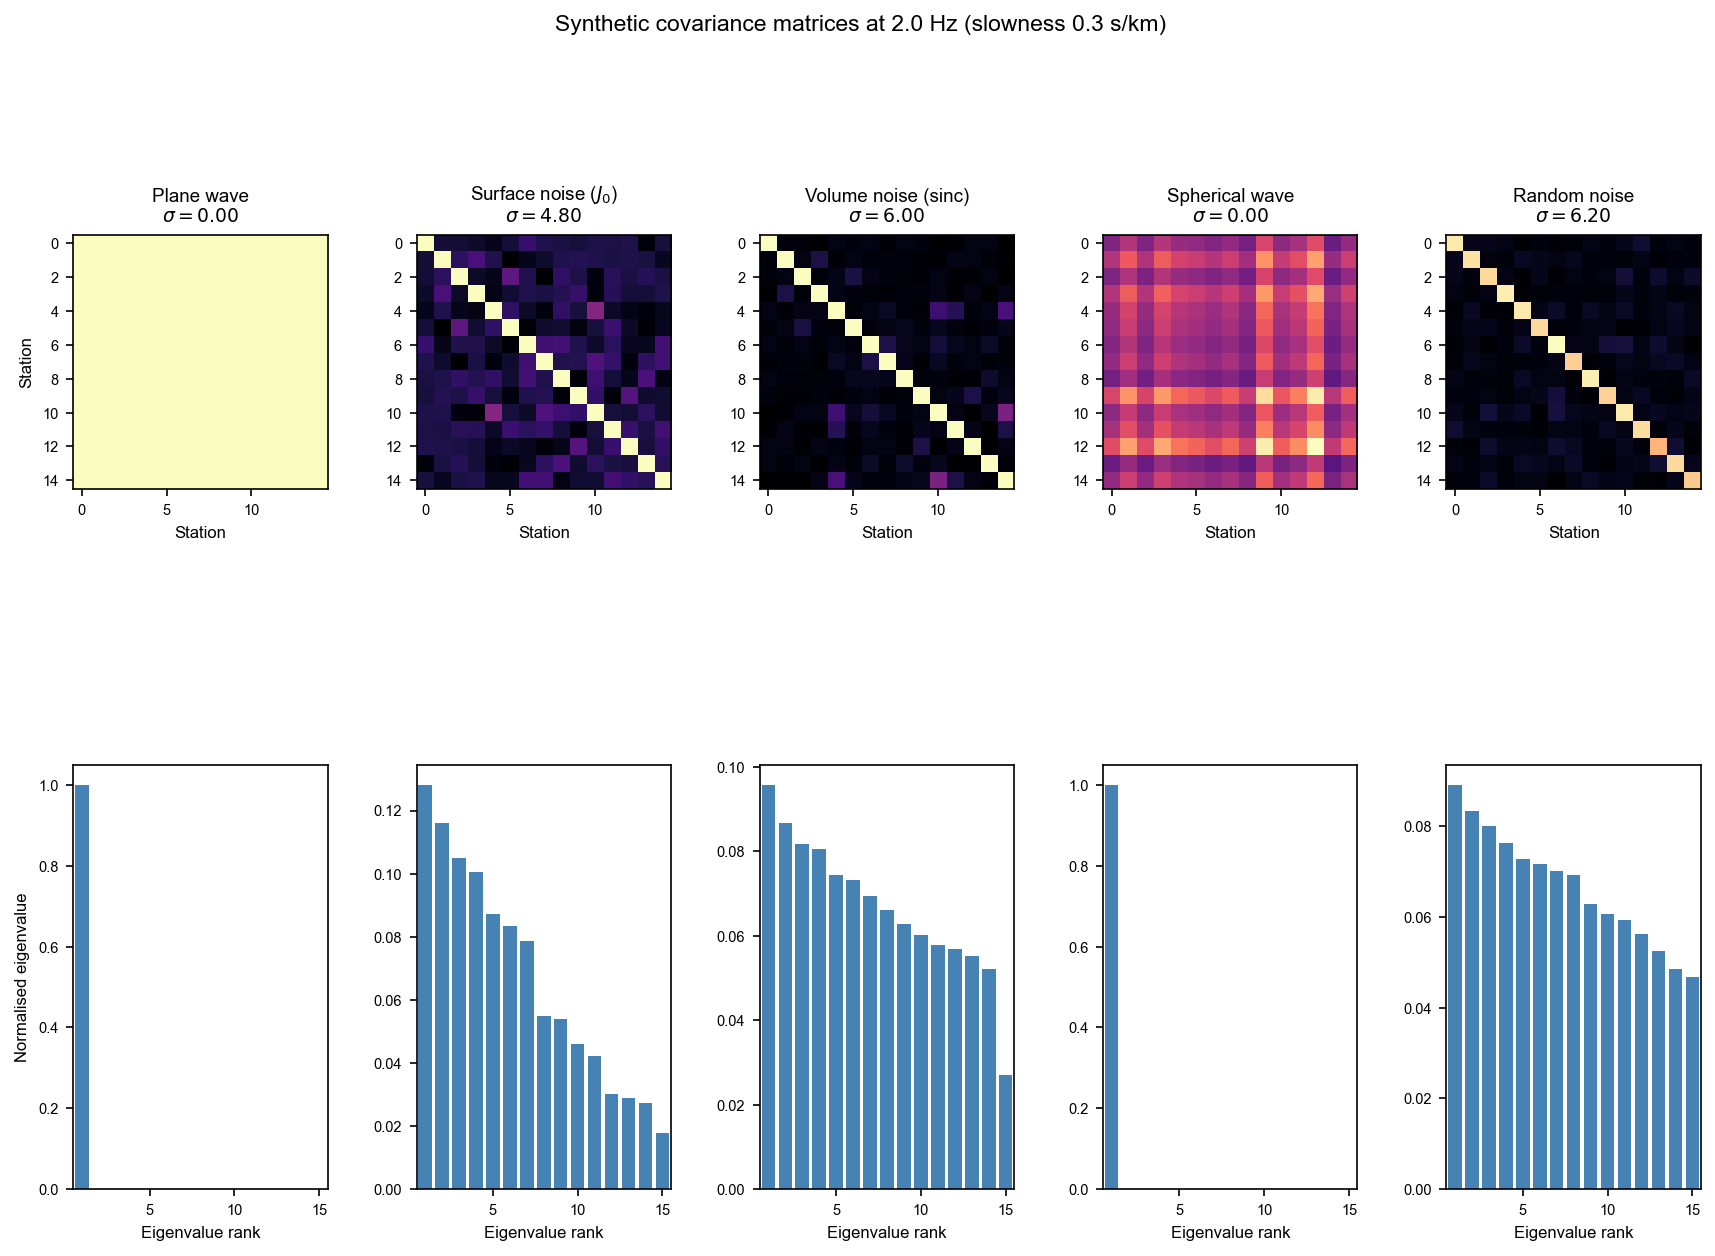

In [5]:
models = [
    (cov_plane, "Plane wave"),
    (cov_surface, "Surface noise ($J_0$)"),
    (cov_volume, "Volume noise (sinc)"),
    (cov_spherical, "Spherical wave"),
    (cov_noise, "Random noise"),
]

fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, len(models), figure=fig, hspace=0.45, wspace=0.35)

for col, (cov, label) in enumerate(models):
    # Normalised modulus
    ax_mat = fig.add_subplot(gs[0, col])
    modulus = np.abs(cov)
    ax_mat.imshow(
        modulus / modulus.max(),
        vmin=0,
        vmax=1,
        cmap="magma",
        aspect="equal",
        interpolation="nearest",
    )
    sw = float(cov.coherence(kind="spectral_width"))
    ax_mat.set_title(f"{label}\n$\\sigma={sw:.2f}$", fontsize=9)
    ax_mat.set_xlabel("Station", fontsize=8)
    if col == 0:
        ax_mat.set_ylabel("Station", fontsize=8)
    ax_mat.tick_params(labelsize=7)

    # Eigenvalue spectrum
    eigenvalues = np.linalg.eigvalsh(cov)
    eigenvalues = np.sort(eigenvalues.real)[::-1]
    eigenvalues = np.maximum(eigenvalues, 0)  # clip numerical noise
    eigenvalues /= eigenvalues.sum()  # normalise

    ax_eig = fig.add_subplot(gs[1, col])
    ax_eig.bar(
        range(1, n_stations + 1), eigenvalues, color="steelblue", width=0.8
    )
    ax_eig.set_xlabel("Eigenvalue rank", fontsize=8)
    if col == 0:
        ax_eig.set_ylabel("Normalised eigenvalue", fontsize=8)
    ax_eig.set_xlim(0.5, n_stations + 0.5)
    ax_eig.tick_params(labelsize=7)

fig.suptitle(
    f"Synthetic covariance matrices at {frequency} Hz "
    f"(slowness {slowness} s/km)",
    fontsize=11,
)
plt.show()

## Interpretation

| Model | Rank | Spectral width $\sigma$ | Physical interpretation |
|---|---|---|---|
| Plane wave | 1 | 0 (minimum) | Single coherent propagating wave |
| Surface noise | $N$ | intermediate | Isotropic 2-D diffuse field |
| Volume noise | $N$ | intermediate | Isotropic 3-D diffuse field |
| Spherical wave | 1 | 0 (minimum) | Point source, geometrical spreading |
| Random noise | $N$ | $(N-1)/2$ (maximum) | Fully incoherent field |

The spectral width $\sigma = \sum_{i=0}^{N-1} i\,\lambda_i$ (normalised eigenvalues
sorted descending) ranges from 0 (rank-1, energy at index 0) to $(N-1)/2$
(uniform distribution, fully incoherent).  It is monitored by
`CovarianceMatrix.coherence(kind="spectral_width")` in real-data workflows.